In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('data.csv').to_numpy()

In [3]:
data = (data - data.mean(axis=1).reshape(-1, 1)) / data.std(axis=1).reshape(-1, 1)

In [4]:
train_length = round(len(data) * 0.8)

In [5]:
train_data = torch.tensor(data[:train_length], dtype=torch.float32)
test_data = torch.tensor(data[train_length:], dtype=torch.float32)
all_data = torch.tensor(data, dtype=torch.float32)

In [6]:
train_loader = DataLoader(TensorDataset(train_data), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(test_data), batch_size=16, shuffle=False)
all_loader = DataLoader(TensorDataset(all_data), batch_size=16, shuffle=True)

In [7]:
# Сверточный автокодировщик
class ConvAutoencoder(nn.Module):
    def __init__(self, bottleneck_size):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, stride=2),  # (B, 8, 743) o1
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=3, stride=2),  # (B, 16, 371) o1
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, stride=2),  # (B, 32, 185) o1
            nn.ReLU(),
            nn.Conv1d(32, 55, kernel_size=3, stride=2),  # (B, 64, 92) o1
            nn.Flatten(),
            nn.Linear(55 * 92, bottleneck_size)
            
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_size, 55 * 92),
            nn.Unflatten(1, (55, 92)),
            nn.ConvTranspose1d(55, 32, kernel_size=3, stride=2),  # (B, 32, 185)
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=3, stride=2),  # (B, 16, 371)
            nn.ReLU(),
            nn.ConvTranspose1d(16, 8, kernel_size=3, stride=2),  # (B, 8, 743)
            nn.ReLU(),
            nn.ConvTranspose1d(8, 1, kernel_size=3, stride=2, output_padding=1),  # (B, 1, 1488)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
model = ConvAutoencoder(bottleneck_size=48).to(device)

In [10]:
k = 0
for param in model.parameters():
    if param.requires_grad:
        k += torch.prod(torch.tensor(param.size()))
print(f'Model has {k} trainable parameters')

Model has 505484 trainable parameters


In [11]:
optimizer = optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

In [12]:
all_train_losses = []
train_losses = []
test_losses = []

In [13]:
epochs = 25

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in train_loader:
        batch = batch[0].unsqueeze(1).to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        all_train_losses.append(loss.item())
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')
    train_losses.append(avg_loss)
    
    model.eval()
    avg_test_loss = 0
    with torch.no_grad():
        for batch in test_loader:
            batch = batch[0].unsqueeze(1).to(device)
            preds = model(batch)
            loss = criterion(preds, batch)
            
            avg_test_loss += loss.item()
    avg_test_loss /= len(test_loader)
    test_losses.append(avg_test_loss)
    print(f'Test Loss: {avg_test_loss:.4f}')

Epoch 1, Loss: 0.8945
Test Loss: 0.6498
Epoch 2, Loss: 0.5915
Test Loss: 0.5683
Epoch 3, Loss: 0.5473
Test Loss: 0.5307
Epoch 4, Loss: 0.5136
Test Loss: 0.5080
Epoch 5, Loss: 0.4893
Test Loss: 0.4789
Epoch 6, Loss: 0.4698
Test Loss: 0.4643
Epoch 7, Loss: 0.4613
Test Loss: 0.4544
Epoch 8, Loss: 0.4525
Test Loss: 0.4467
Epoch 9, Loss: 0.4444
Test Loss: 0.4406
Epoch 10, Loss: 0.4393
Test Loss: 0.4349
Epoch 11, Loss: 0.4321
Test Loss: 0.4275
Epoch 12, Loss: 0.4238
Test Loss: 0.4168
Epoch 13, Loss: 0.4090
Test Loss: 0.4014
Epoch 14, Loss: 0.3915
Test Loss: 0.3864
Epoch 15, Loss: 0.3772
Test Loss: 0.3731
Epoch 16, Loss: 0.3644
Test Loss: 0.3615
Epoch 17, Loss: 0.3528
Test Loss: 0.3529
Epoch 18, Loss: 0.3446
Test Loss: 0.3467
Epoch 19, Loss: 0.3385
Test Loss: 0.3428
Epoch 20, Loss: 0.3315
Test Loss: 0.3382
Epoch 21, Loss: 0.3285
Test Loss: 0.3355
Epoch 22, Loss: 0.3244
Test Loss: 0.3339
Epoch 23, Loss: 0.3218
Test Loss: 0.3330
Epoch 24, Loss: 0.3205
Test Loss: 0.3326
Epoch 25, Loss: 0.3188
Te

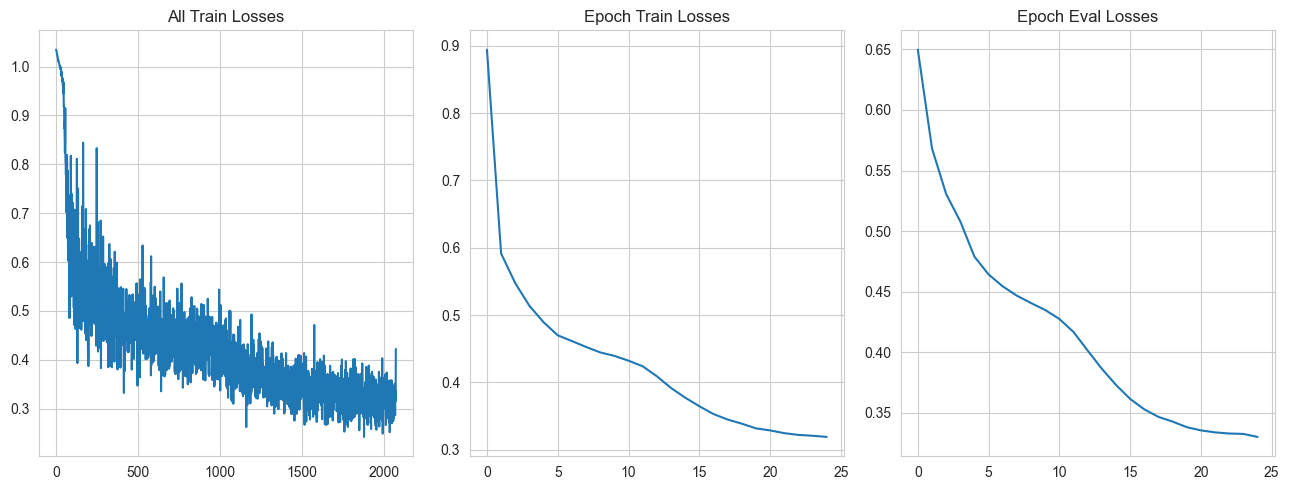

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
axes[0].plot(all_train_losses)
axes[0].set_title('All Train Losses')
axes[1].plot(train_losses)
axes[1].set_title('Epoch Train Losses')
axes[2].plot(test_losses)
axes[2].set_title('Epoch Eval Losses')
plt.tight_layout()
plt.show()

In [15]:
model = ConvAutoencoder(bottleneck_size=48).to(device)
optimizer = optim.Adam(model.parameters(), lr=3e-4)

epochs = 25

for epoch in range(epochs):
    avg_loss = 0
    model.train()
    for batch in all_loader:
        batch = batch[0].unsqueeze(1).to(device)
        preds = model(batch)
        loss = criterion(preds, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        avg_loss += loss.item()
    avg_loss /= len(train_loader)
    print(f'Epoch {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch 1, Loss: 1.2486
Epoch 2, Loss: 0.7087
Epoch 3, Loss: 0.5813
Epoch 4, Loss: 0.5571
Epoch 5, Loss: 0.5387
Epoch 6, Loss: 0.5138
Epoch 7, Loss: 0.4836
Epoch 8, Loss: 0.4548
Epoch 9, Loss: 0.4346
Epoch 10, Loss: 0.4217
Epoch 11, Loss: 0.4133
Epoch 12, Loss: 0.4062
Epoch 13, Loss: 0.4019
Epoch 14, Loss: 0.3978
Epoch 15, Loss: 0.3953
Epoch 16, Loss: 0.3928
Epoch 17, Loss: 0.3904
Epoch 18, Loss: 0.3886
Epoch 19, Loss: 0.3871
Epoch 20, Loss: 0.3852
Epoch 21, Loss: 0.3835
Epoch 22, Loss: 0.3817
Epoch 23, Loss: 0.3805
Epoch 24, Loss: 0.3792
Epoch 25, Loss: 0.3775


In [63]:
# torch.save(model.state_dict(), 'models/CAE.pt')

In [16]:
errors = []
encoded = []
reconstructed = []
with torch.no_grad():
    for sample in all_data:
        inputs = sample.view(1, 1, -1).to(device)
        res = model(inputs).cpu().detach().flatten()
        reconstruction_error = criterion(res, sample)
        errors.append(reconstruction_error.numpy())
        
        features = model.encoder(inputs).view(-1)
        encoded.append(features.cpu().detach().numpy())
        
        reconstructed.append(res.view(-1).cpu().detach().numpy())

errors = np.array(errors)
encoded = np.array(encoded)
reconstructed = np.array(reconstructed)

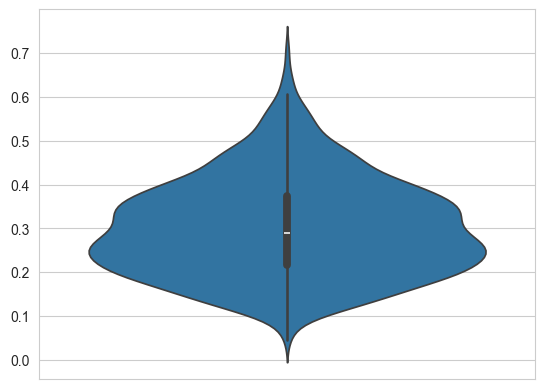

In [17]:
sns.violinplot(errors)
plt.show()

In [18]:
np.quantile(errors, 0.99)

0.5864483720064161

In [19]:
np.column_stack((np.argsort(-errors), -np.sort(-errors)))

array([[1.22500000e+03, 7.10505903e-01],
       [2.80000000e+01, 7.07664669e-01],
       [9.08000000e+02, 6.86529756e-01],
       ...,
       [1.10200000e+03, 5.91255091e-02],
       [6.54000000e+02, 5.33767603e-02],
       [2.23000000e+02, 4.57122922e-02]])

In [ ]:
# 1225.0	0.710506
# 28.0	0.707665
# 908.0	0.686530
# 1578.0	0.656454
# 554.0	0.653663
# 142.0	0.646521
# 1178.0	0.638603
# 1034.0	0.630799
# 4.0	0.627257
# 1146.0	0.623285

In [23]:
def plot_sample(sample):
    _, ax = plt.subplots(figsize=(20, 5))
    ax.plot(data[sample], label='True')
    pred_row = reconstructed[sample]
    ax.plot(pred_row, label='Predicted')
    mse = np.linalg.norm(data[sample] - pred_row) ** 2 / len(data[sample])
    ax.set_title(f'Model Prediction VS True Series, MSE: {mse.round(2)}, Sample: {sample}')
    plt.legend()
    plt.show()

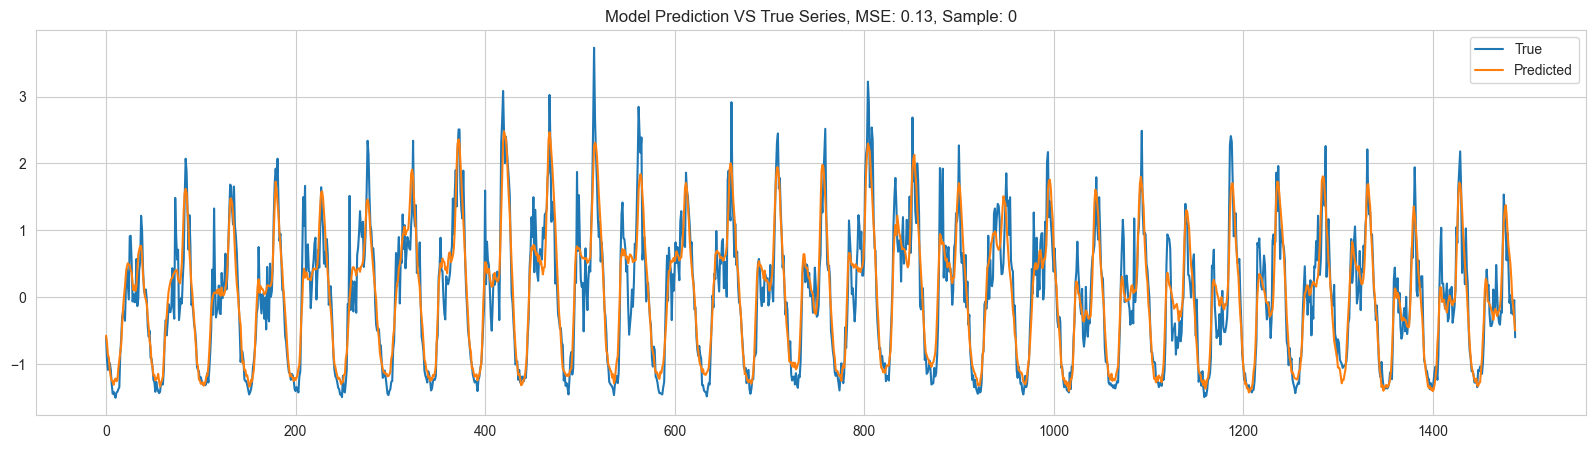

In [24]:
plot_sample(0)

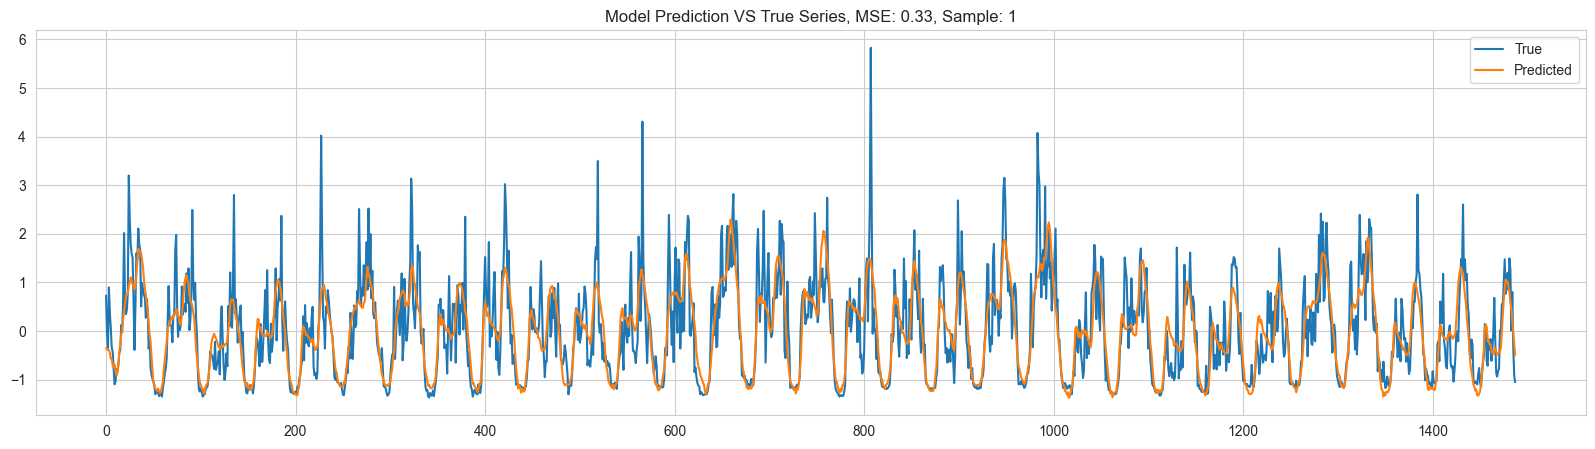

In [25]:
plot_sample(1)

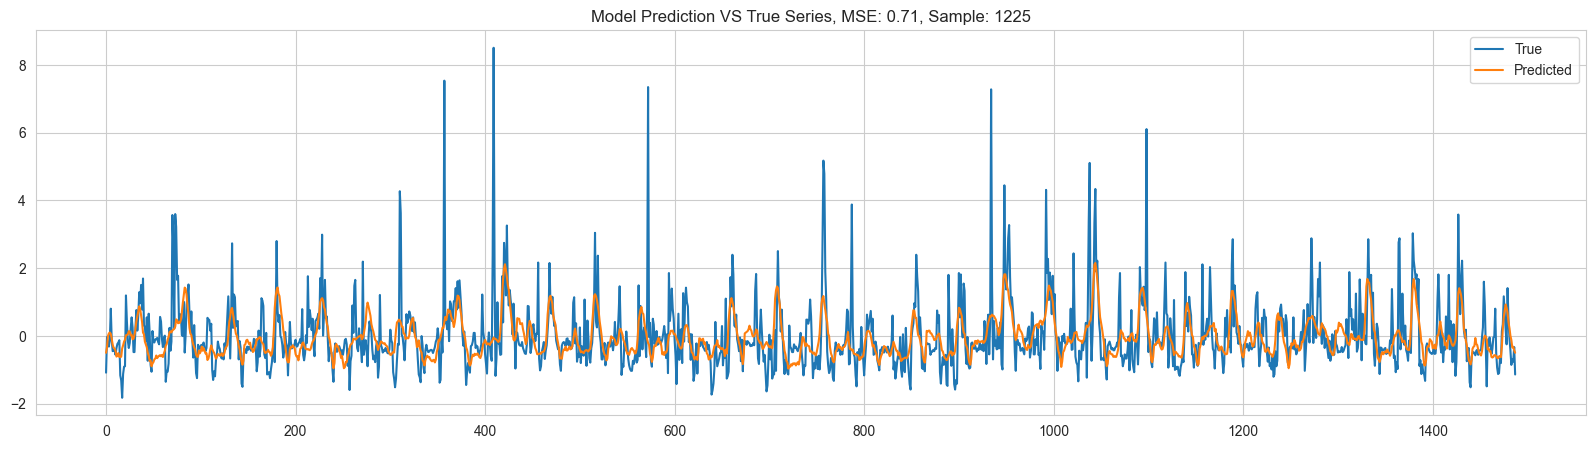

In [26]:
plot_sample(1225)

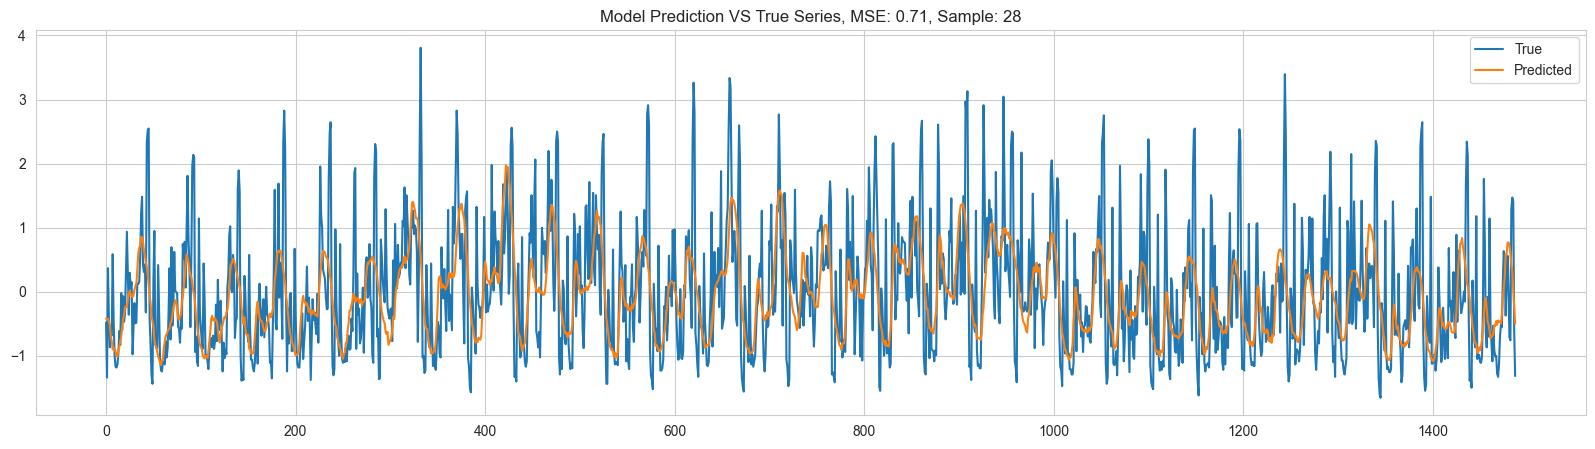

In [27]:
plot_sample(28)

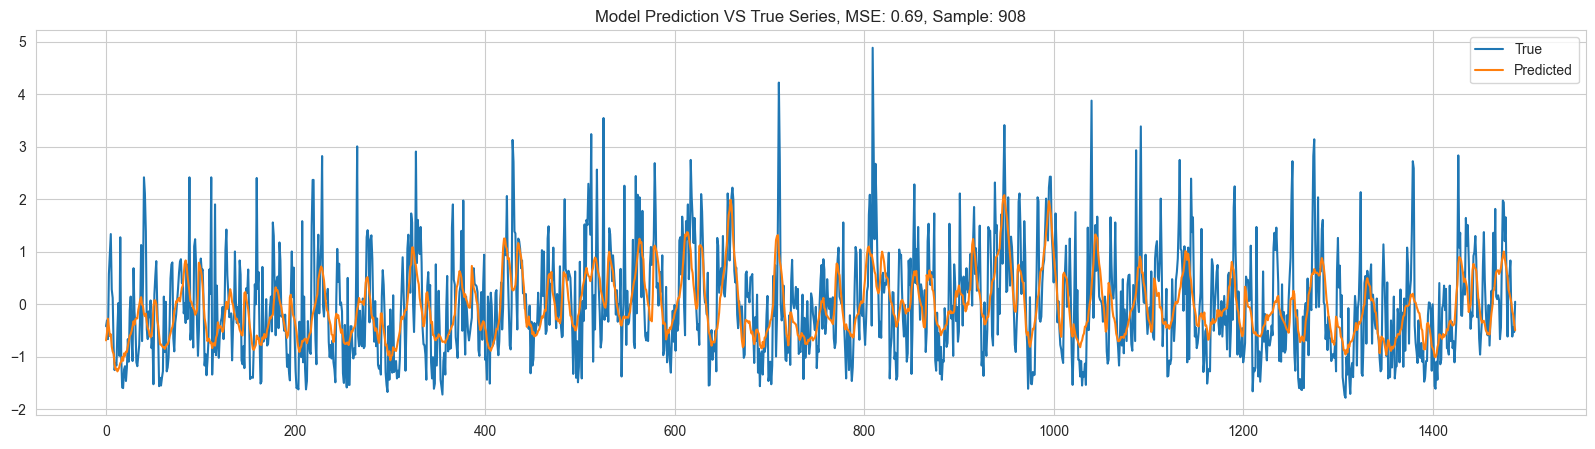

In [28]:
plot_sample(908)

In [30]:
encoded_norm = (encoded - encoded.mean(axis=0)) / encoded.std(axis=0)

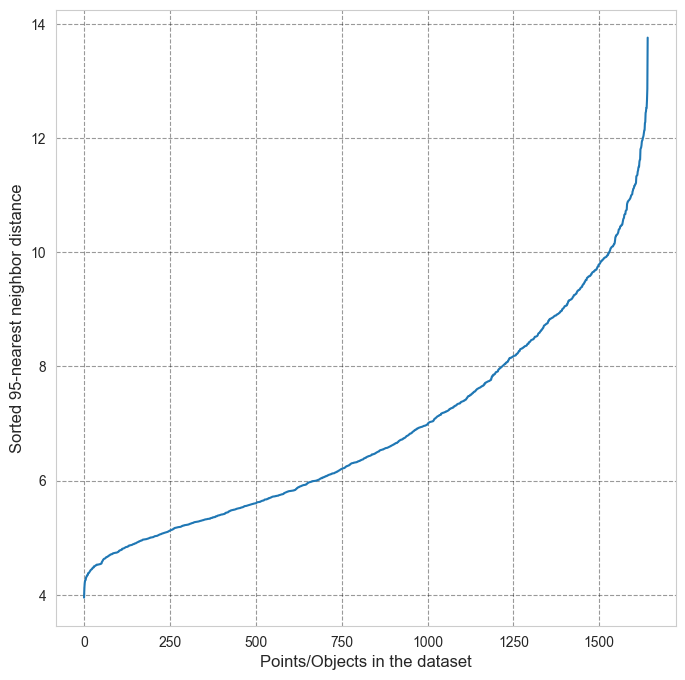

In [31]:
from sklearn.neighbors import NearestNeighbors


def get_kdist_plot(X=None, k=None, radius_nbrs=1.0):

    nbrs = NearestNeighbors(n_neighbors=k, radius=radius_nbrs).fit(X)

    # For each point, compute distances to its k-nearest neighbors
    distances, indices = nbrs.kneighbors(X) 
                                       
    distances = np.sort(distances, axis=0)
    distances = distances[:, k-1]

    # Plot the sorted K-nearest neighbor distance for each point in the dataset
    plt.figure(figsize=(8,8))
    plt.plot(distances)
    plt.xlabel('Points/Objects in the dataset', fontsize=12)
    plt.ylabel('Sorted {}-nearest neighbor distance'.format(k), fontsize=12)
    plt.grid(True, linestyle="--", color='black', alpha=0.4)
    plt.show()
    plt.close()


k = 2 * encoded_norm.shape[-1] - 1 # k=2*{dim(dataset)} - 1
get_kdist_plot(X=encoded_norm, k=k)

In [48]:
from sklearn.cluster import DBSCAN

# Создаем объект DBSCAN
dbscan = DBSCAN(eps=10.25, min_samples=10)

# Проводим кластеризацию данных
clusters = dbscan.fit_predict(encoded_norm)

# Ищем объекты, отнесенные к кластеру -1 (это аномалии)
anomalies_indices = np.where(clusters == -1)[0]
anomalies_indices

array([  56,  528,  584,  647,  834,  921, 1014, 1119, 1416, 1486],
      dtype=int64)

In [ ]:
# 56,  528,  584,  647,  834,  921, 1014, 1119, 1416, 1486
# 56,  528, 1486

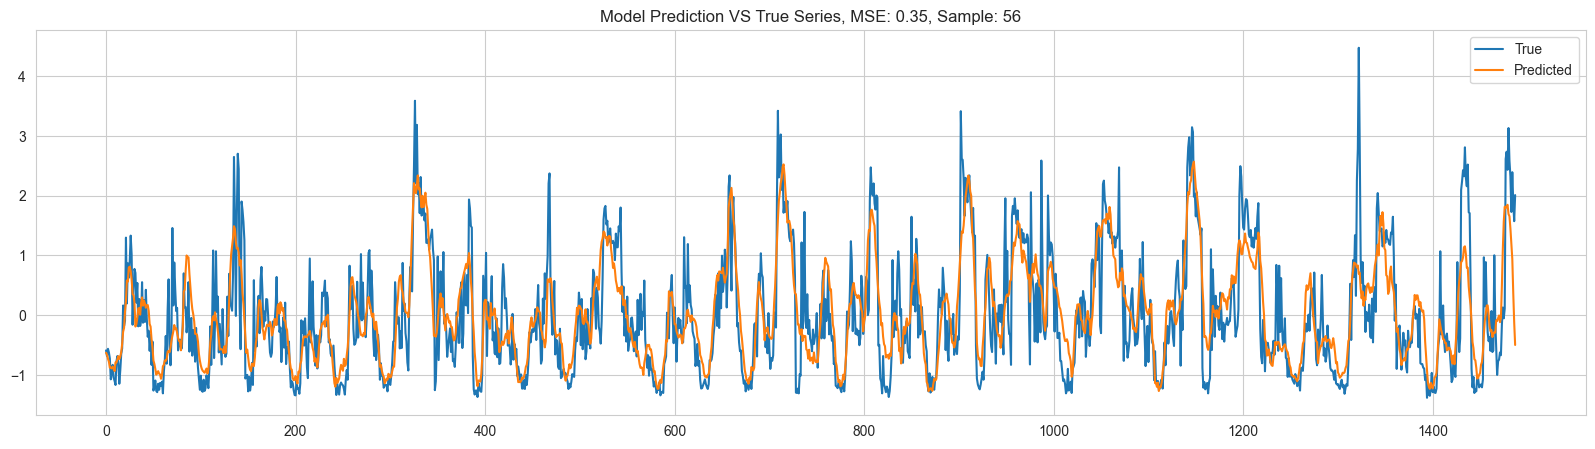

In [49]:
plot_sample(56)

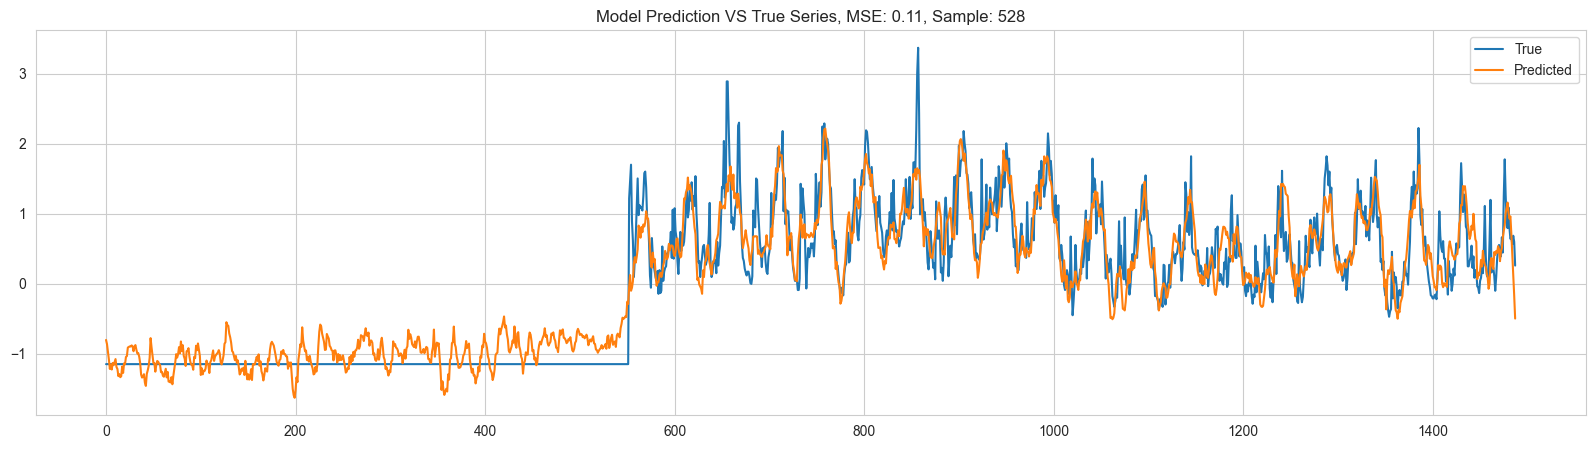

In [50]:
plot_sample(528)

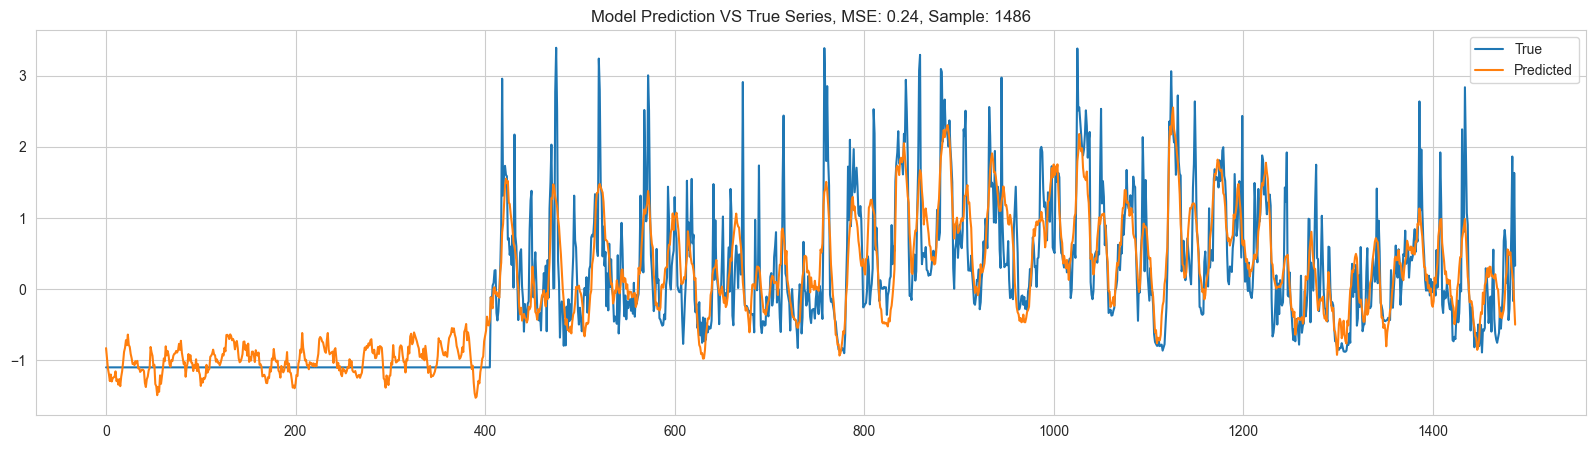

In [51]:
plot_sample(1486)

In [18]:
import matplotlib

size = 15
matplotlib.rc('font', size=size)
matplotlib.rc('axes', titlesize=size)

In [56]:
medians = np.median(encoded_norm, axis=0)
middle = np.repeat(np.inf, 4)
cur_min = np.inf
for sample in encoded_norm:
    dist = np.dot(sample - medians, sample - medians)
    if dist < cur_min:
        cur_min = dist
        middle = sample
q = 0.001
dists = np.linalg.norm(encoded_norm - middle, axis=1)
band = max(np.quantile(dists, q), 1e-3)
band

3.223900143623352

In [57]:
from sklearn.neighbors import KernelDensity

kde = KernelDensity(kernel='gaussian', bandwidth=band)
kde.fit(encoded_norm)
kde_scores = kde.score_samples(encoded_norm)

In [58]:
min_max = 1 - (kde_scores - kde_scores.min()) / (kde_scores.max() - kde_scores.min())
np.vstack((-np.sort(-min_max), np.argsort(-min_max))).T

array([[1.00000000e+00, 5.28000000e+02],
       [9.94268708e-01, 6.47000000e+02],
       [9.82601303e-01, 9.21000000e+02],
       ...,
       [1.54771856e-02, 8.35000000e+02],
       [2.84257603e-03, 4.38000000e+02],
       [0.00000000e+00, 1.50500000e+03]])

In [ ]:
# 1.000000,528.0
# 0.994269,647.0
# 0.982601,921.0
# 0.982300,1416.0
# 0.980992,1486.0
# 0.976472,1066.0
# 0.970141,56.0
# 0.965128,969.0
# 0.963733,720.0
# 0.956667,1119.0


<Axes: >

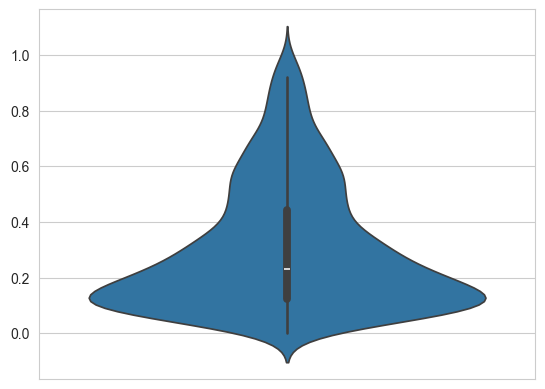

In [59]:
sns.violinplot(min_max)

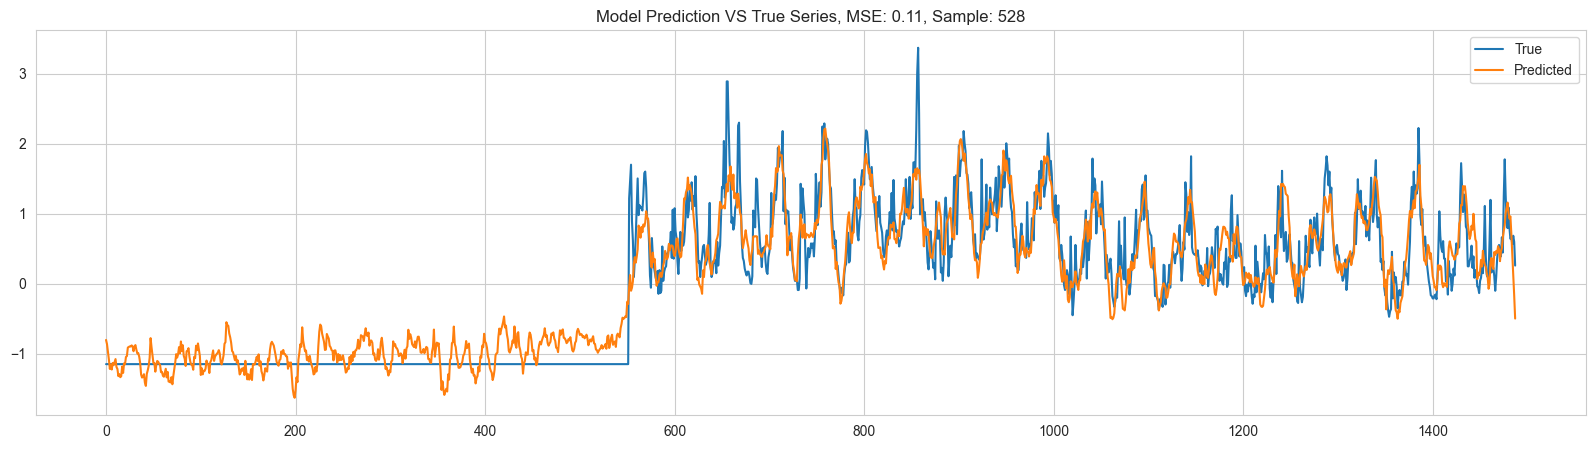

In [60]:
plot_sample(528)

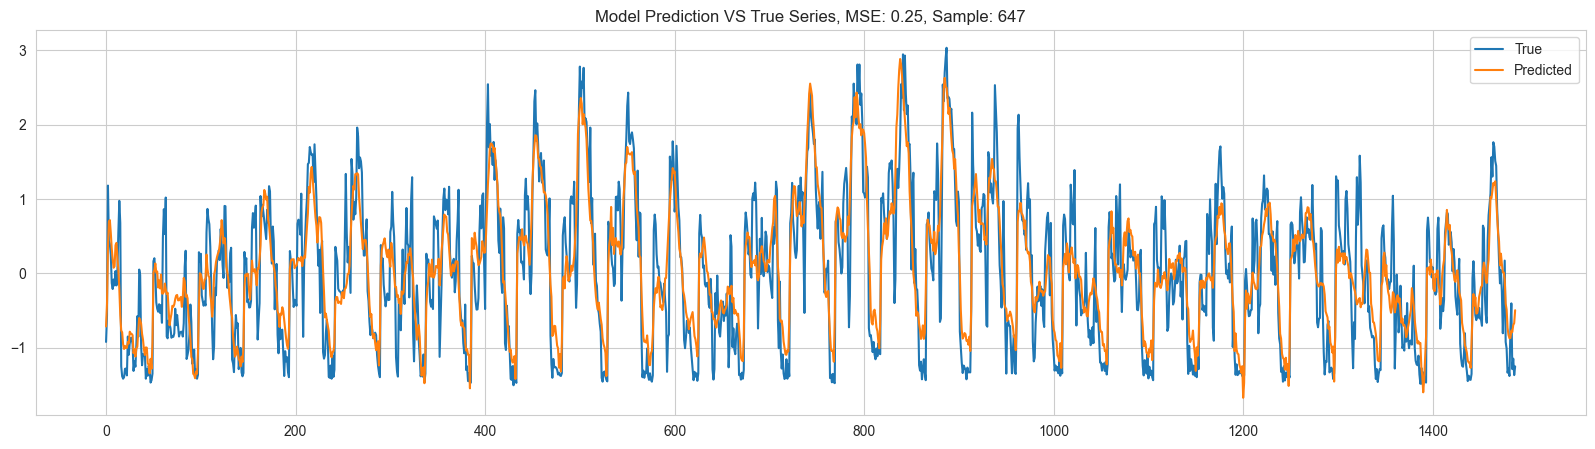

In [61]:
plot_sample(647)

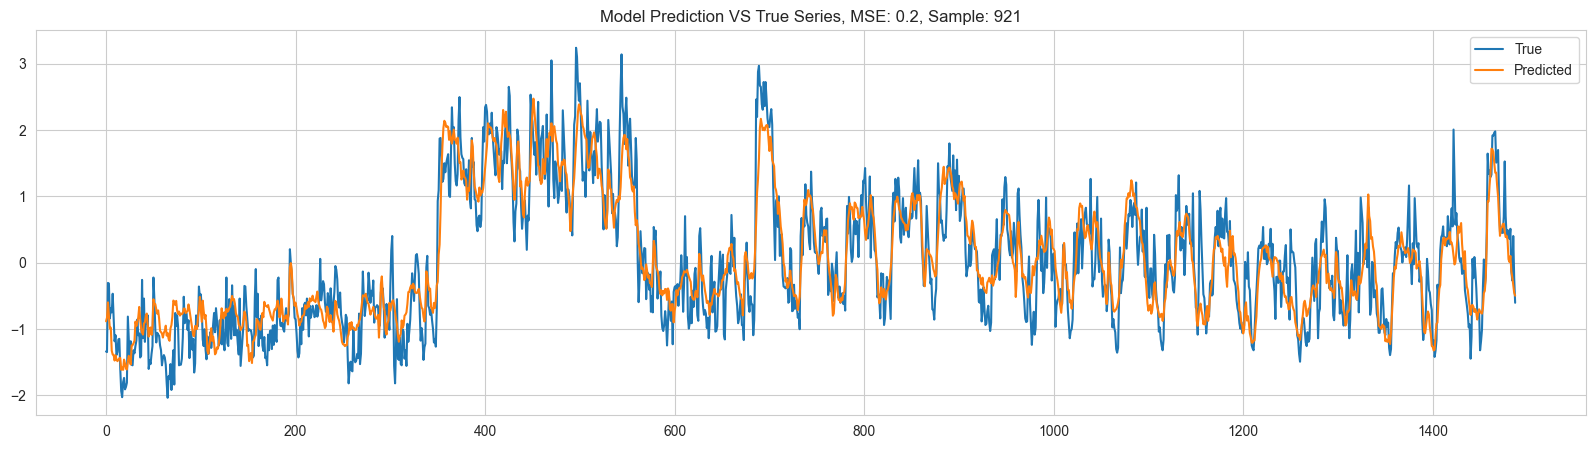

In [62]:
plot_sample(921)